In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}, Device: {device}")

import torch.nn as nn
import numpy as np

PyTorch version: 2.5.1, Device: cuda


In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transformation = transforms.Compose(
    [transforms.ToTensor(),  # [0,255] uint8 → [0,1] float32    # TF equivalent: tf.cast(x, tf.float32) / 255.0
     transforms.Normalize((0.5,), (0.5,))  # optional: normalize to [-1, 1]
     ])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transformation)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transformation)

# TF: model.fit(train_X, train_Y, batch_size=128)
# PT: DataLoader handles batching, shuffling
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Training batches: 391
Test batches:     79


In [3]:
image_size = 32
patch_size = 4
num_patches = (image_size // patch_size) ** 2  # 64
d_model = 64
num_heads = 4
num_layers = 3
num_classes = 10

assert image_size % patch_size == 0
print(f"num_patches: {num_patches}")

num_patches: 64


In [4]:
# ══════════════════════════════════════════════════════
# PATCH EMBEDDING
# TF: tf.keras.layers.Layer with Conv2D inside
# PT: nn.Module with nn.Conv2d inside
# Key difference: PyTorch Conv2d expects [batch, C, H, W]
# ══════════════════════════════════════════════════════
class PatchEmbedding(nn.Module):  # TF: tf.keras.layers.Layer
    def __init__(self):
        super().__init__()
        # TF: Conv2D(filters=d_model, kernel_size=patch_size, strides=patch_size)
        # PT: Conv2d(in_channels, out_channels, kernel_size, stride)
        # Note: in_channels=3 (RGB) must be specified in PyTorch, TF infers it
        self.proj = nn.Conv2d(in_channels=3, out_channels=d_model,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):  # TF: def call(self, x)
        # Input: [batch, 3, 32, 32]        # TF input: [batch, 32, 32, 3]
        x = self.proj(x)  # [batch, d_model, 8, 8]
        x = x.flatten(2)  # [batch, d_model, 64]   TF: tf.reshape(x, [batch, -1, d_model])
        x = x.transpose(1, 2)  # [batch, 64, d_model]   PyTorch needs explicit transpose
        return x


# ══════════════════════════════════════════════════════
# POSITIONAL ENCODING
# TF: self.add_weight(...)
# PT: nn.Parameter(...)
# ══════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    def __init__(self):
        super().__init__()
        # TF: self.pos_emb = self.add_weight(shape=(1, num_patches, d_model), ...)
        # PT: nn.Parameter is the equivalent of add_weight — a trainable tensor
        self.pos_emb = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)  # stddev=0.02, same as TF

    def forward(self, x):
        return x + self.pos_emb


# ══════════════════════════════════════════════════════
# TRANSFORMER BLOCK
# TF: tf.keras.layers.MultiHeadAttention
# PT: nn.MultiheadAttention
# Key difference: PT MHA expects [seq_len, batch, d_model] by default
#                 OR set batch_first=True to match TF's [batch, seq_len, d_model]
# ══════════════════════════════════════════════════════
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()

        # TF: MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        # PT: MultiheadAttention(embed_dim, num_heads)
        # Note: PT uses embed_dim (total), TF uses key_dim (per head)
        # embed_dim = num_heads * key_dim = 4 * 16 = 64
        self.mha = nn.MultiheadAttention(embed_dim=d_model,
                                         num_heads=num_heads,
                                         dropout=0.1,
                                         batch_first=True)  # ← makes it [batch, seq, dim] like TF

        # FFN — identical structure to TF version
        # TF: tf.keras.Sequential([Dense(256, activation='gelu'), Dropout, Dense(d_model), Dropout])
        # PT: nn.Sequential([Linear(d_model, 256), GELU, Dropout, Linear(256, d_model), Dropout])
        # Note: PT Linear = TF Dense, PT GELU must be added explicitly as a layer
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(0.1),
        )

        # Note: PT requires the normalized shape explicitly
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, training=False):
        # TF: self.mha(query=x, key=x, value=x, training=training)
        # PT: self.mha(query, key, value) — returns (output, attention_weights)
        #     need_weights=False skips computing attention weights (faster)
        attn_out, attn_weights = self.mha(x, x, x, need_weights=False)
        attn_out = self.dropout(attn_out)
        x = self.norm1(x + attn_out)  # pre/post norm — same as TF

        ffn_out = self.ffn(x)
        return self.norm2(x + ffn_out)


# ══════════════════════════════════════════════════════
# VIT MODEL
# TF: tf.keras.Model
# PT: nn.Module
# ══════════════════════════════════════════════════════
class ViT(nn.Module):  # TF: tf.keras.Model
    def __init__(self):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        self.pos_encoding = PositionalEncoding()

        # TF: setattr trick to register blocks
        # PT: nn.ModuleList — proper way to register a list of modules
        #     Plain Python list won't have parameters tracked by PyTorch
        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock() for _ in range(num_layers)]
        )

        # TF: GlobalAveragePooling1D()
        # PT: no direct equivalent layer — use torch.mean() in forward()
        # self.pool = nn.AdaptiveAvgPool1d(1)  # alternative

        # TF: Dense(num_classes)  — no activation, from_logits=True in loss
        # PT: nn.Linear(d_model, num_classes) — same idea
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):  # TF: def call(self, x)
        x = self.patch_embed(x)  # [batch, 64, d_model]
        x = self.pos_encoding(x)  # [batch, 64, d_model]

        for block in self.transformer_blocks:
            x = block(x)  # [batch, 64, d_model]

        # TF: GlobalAveragePooling1D() averages over the sequence dimension (dim=1)
        # PT: torch.mean over dim=1
        x = x.mean(dim=1)  # [batch, d_model]

        return self.classifier(x)  # [batch, num_classes] — raw logits


# Build model and move to device
# TF: model = ViT()  — no need to specify device
# PT: must explicitly move model to GPU/CPU
model = ViT().to(device)

In [5]:
# Verify shapes
# TF: dummy_input = tf.random.normal([1, 32, 32, 3])
# PT: torch.randn([1, 3, 32, 32])  ← note channel-first format
dummy_input = torch.randn(1, 3, 32, 32).to(device)
dummy_output = model(dummy_input)
print(f"Output shape: {dummy_output.shape}")  # [1, 10]

# Model summary
# TF: model.summary()
# PT: no built-in summary, use torchinfo
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))


Output shape: torch.Size([1, 10])


Layer (type:depth-idx)                   Output Shape              Param #
ViT                                      [1, 10]                   --
├─PatchEmbedding: 1-1                    [1, 64, 64]               --
│    └─Conv2d: 2-1                       [1, 64, 8, 8]             3,136
├─PositionalEncoding: 1-2                [1, 64, 64]               4,096
├─ModuleList: 1-3                        --                        --
│    └─TransformerBlock: 2-2             [1, 64, 64]               --
│    │    └─MultiheadAttention: 3-1      [1, 64, 64]               16,640
│    │    └─Dropout: 3-2                 [1, 64, 64]               --
│    │    └─LayerNorm: 3-3               [1, 64, 64]               128
│    │    └─Sequential: 3-4              [1, 64, 64]               33,088
│    │    └─LayerNorm: 3-5               [1, 64, 64]               128
│    └─TransformerBlock: 2-3             [1, 64, 64]               --
│    │    └─MultiheadAttention: 3-6      [1, 64, 64]               16

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# TF: SparseCategoricalCrossentropy(from_logits=True)
# PT: CrossEntropyLoss() — always expects logits (from_logits=True is the default)
#     Also: TF SparseCategorical = integer labels, PT CrossEntropyLoss = same
criterion = nn.CrossEntropyLoss()

# TF: ReduceLROnPlateau callback
# PT: torch.optim.lr_scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6, verbose=True)


C:\Users\zabeeh\anaconda3\envs\v_torch_gpu_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
def train(model, loader, optimizer, criterion):
    # TF: training=True is passed automatically during model.fit
    # PT: model.train() sets all layers to training mode (enables Dropout, BatchNorm)
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch_X, batch_Y in loader:
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        logits = model(batch_X)
        loss = criterion(logits, batch_Y)

        loss.backward()
        optimizer.step()

        # Accumulating results
        total_loss += loss.item() * batch_X.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == batch_Y).sum().item()
        total_samples += batch_X.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion):
    # TF: model.evaluate() — automatic, uses training=False internally
    # PT: model.eval() disables Dropout and BatchNorm updates
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    # TF: no equivalent needed — gradients not computed during evaluate()
    # PT: torch.no_grad() disables gradient computation → faster + less memory
    with torch.no_grad():
        for batch_X, batch_Y in loader:
            batch_X = batch_X.to(device)
            batch_Y = batch_Y.to(device)

            logits = model(batch_X)
            loss = criterion(logits, batch_Y)

            total_loss += loss.item() * batch_X.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == batch_Y).sum().item()
            total_samples += batch_X.size(0)

    return total_loss / total_samples, total_correct / total_samples


epochs = 10
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_weights = None

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)

    # TF: ReduceLROnPlateau callback does this automatically
    # PT: must call scheduler.step() manually with the monitored metric
    scheduler.step(val_loss)

    # Store history
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch + 1:02d}/{epochs} — "
          f"loss: {train_loss:.4f} — acc: {train_acc:.4f} — "
          f"val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f} — "
          f"lr: {optimizer.param_groups[0]['lr']:.2e}")

    # EarlyStopping(patience=15, restore_best_weights=True)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        #restore_best_weights=True saves best weights automatically
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            model.load_state_dict(best_weights)  # restore best weights
            break


Epoch 01/10 — loss: 1.8306 — acc: 0.3250 — val_loss: 1.6116 — val_acc: 0.4050 — lr: 3.00e-04
Epoch 02/10 — loss: 1.5088 — acc: 0.4530 — val_loss: 1.4070 — val_acc: 0.4919 — lr: 3.00e-04
Epoch 03/10 — loss: 1.3372 — acc: 0.5168 — val_loss: 1.3090 — val_acc: 0.5291 — lr: 3.00e-04
Epoch 04/10 — loss: 1.2440 — acc: 0.5505 — val_loss: 1.2330 — val_acc: 0.5520 — lr: 3.00e-04
Epoch 05/10 — loss: 1.1802 — acc: 0.5724 — val_loss: 1.1708 — val_acc: 0.5765 — lr: 3.00e-04
Epoch 06/10 — loss: 1.1269 — acc: 0.5924 — val_loss: 1.1475 — val_acc: 0.5839 — lr: 3.00e-04
Epoch 07/10 — loss: 1.0819 — acc: 0.6107 — val_loss: 1.0953 — val_acc: 0.6119 — lr: 3.00e-04
Epoch 08/10 — loss: 1.0450 — acc: 0.6229 — val_loss: 1.0783 — val_acc: 0.6185 — lr: 3.00e-04
Epoch 09/10 — loss: 1.0123 — acc: 0.6370 — val_loss: 1.0637 — val_acc: 0.6228 — lr: 3.00e-04
Epoch 10/10 — loss: 0.9779 — acc: 0.6499 — val_loss: 1.0458 — val_acc: 0.6343 — lr: 3.00e-04


In [9]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# ══════════════════════════════════════════════════════
# PREDICTIONS
# TF: logits = model.predict(test_X)
#     probs = tf.nn.softmax(logits)
#     predicted_classes = tf.argmax(probs, axis=-1)
# PT: equivalent below
# ══════════════════════════════════════════════════════
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch_X, batch_Y in test_loader:
        batch_X = batch_X.to(device)
        logits = model(batch_X)
        probs = torch.softmax(logits, dim=-1)  # TF: tf.nn.softmax(logits, axis=-1)
        preds = torch.argmax(probs, dim=-1)  # TF: tf.argmax(probs, axis=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_Y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(f"Prediction accuracy: {(all_preds == all_labels).mean():.4f}")


Test Loss: 1.0458 | Test Accuracy: 0.6343
Prediction accuracy: 0.6343


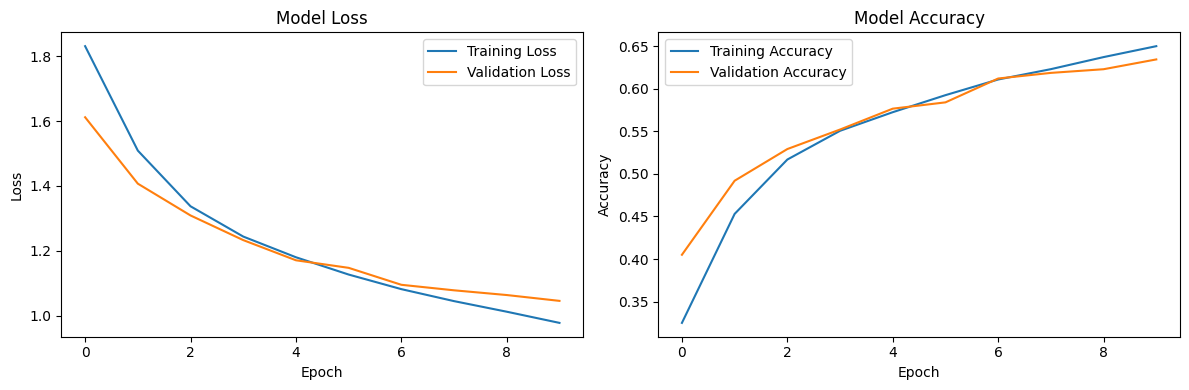

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()